## Imports

In [1]:
import sys
import masserstein
import numpy as np
import pandas as pd
import os
from masserstein import NMRSpectrum, estimate_proportions
import matplotlib.pyplot as plt
import pulp
import pickle
import time
from scipy.stats import cauchy
import math
from textwrap import wrap

In [2]:
results_path = '../../results/additional_analysis/overlapping_simulations/'

## Scenario: overlapping + small unique peaks

### Theory

**1. Properties of Lorentz distribution**

Let us start from describing the basic properties of the Lorentz distribution to understand the further reasoning.

Lorentz distribution (i.e. Cauchy distribution) has two parameters: $x_0$ (location, real) and $\gamma$ (shape, positive).

The formula for PDF is as follows:

$ p(x) = \frac{1}{\pi \gamma \Big[1 + (\frac{x-x_{0}}{\gamma})^2\Big]} $

And for CDF:

$ f(x) = \frac{1}{\pi} \text{arctan}\Big(\frac{x-x_0}{\gamma}\Big) + \frac{1}{2}$

Lorentz distribution is symmetric around $x_0$ which we can see from the formula for PDF.

**2. Our task**

We would like to simulate two lorentzian peaks (i.e. distributions) with some overlap. Let's say that the first distribution has the location parameter $x_0$ and cumulative distribution function $f_0$ and that the second distribution has the location parameter $x_1$ and cumulative distribution function $f_2$. Let's assume that they share the same scale parameter $\gamma$ and that $x_1 > x_0$, i.e. the second distribution is located on the right hand side of the first one.

We would like to be able to change the amount of overlap. Without the loss of generality, we can fix $x_0$ and change only $x_1$. Now, we would like to know how to change $x_1$ to obtain a specific proportion of overlap $P$. So, basically, we would like to get a formula for a function calculating $x_1$ from $P$ somehow.

**3. Solution**

First, let us notice that the point of intersection of the two PDFs is exactly in the middle between $x_0$ and $x_1$, i.e. in $x^{*}=\frac{x_0+x_1}{2}$. (This is due to symmetry of the Lorentz distribution, but can be also explicitly calculated).

To calculate the area of overlap, we need to add two areas: the first one is the area to the left of $x^{*}$ and, at the same time, below $p_1$ and the second one is the area to the right of $x^{*}$ and, at the same time, below $p_0$. From symmetry it is enough to calculate one of them and multiply it by 2.

The area to the right of $x^{*}$ and, at the same time, below $p_1$ is exactly the value of CDF in point $x^*$, i.e. $f_1(\frac{x_0+x_1}{2})$. So the formula for proportion of overlap $P$ as a function of $x_1$ is:

$P = 2 \cdot f_1(\frac{x_0+x_1}{2})$

Now, we need to use the explicit formula for Lorentz distribution's CDF:

$P = \frac{2}{\pi} \text{arctan}\Big(\frac{x_0-x_1}{2\gamma}\Big) + 1$

Now we need to transform this equation to get the formula for $x_1$ as a function of $P$:

$\frac{\pi}{2}(P-1)=\text{arctan}\Big(\frac{x_0-x_1}{2\gamma}\Big)$

$x_1 = -2 \gamma \cdot \text{tan}\Big[\frac{\pi}{2}(P-1) \Big] + x_0$

From trigonometric properties:

$x_1 = 2 \gamma \cdot \text{tan}\Big[\frac{\pi}{2}(1-P) \Big] + x_0$

This is the function that we've been seeking. Note that it makes sense, because for $P=1$ the value is $x_0$ and for $P=0$ is undefined, becuase it is impossible for the two Lorentzian peaks on the real number line to have no overlap.

### Parameters

Set:

In [3]:
first_peak_position = 2.5
scale = 0.03

small_peak_position = 1
scale = 0.03

chemical_shift_axis = np.arange(0, 5, 0.001)
ground_truth_proportions = [0.5, 0.5]

Adjustable:

In [4]:
small_peak_proportion = 0.
shift_diff = 0.

overlap_proportion = np.arange(0.02, 1.01, 0.01)
shift = np.arange(0.001, 0.51, 0.02)

### Components

Set:

In [5]:
def add_in_proportion(main_peak, small_peak, chemical_shift_axis, small_peak_proportion):
    
    component_0 = NMRSpectrum(confs = list(zip(chemical_shift_axis, main_peak)))
    component_0.normalize()
    
    component_1 = NMRSpectrum(confs = list(zip(chemical_shift_axis, small_peak)))
    component_1.normalize(small_peak_proportion / (1 + small_peak_proportion))
    
    result_intensities = np.array(component_0.confs)[:,1] + np.array(component_1.confs)[:,1]
    result = NMRSpectrum(confs = list(zip(chemical_shift_axis, result_intensities)))
    result.normalize()
    
    return result

Adjustable:

In [6]:
def second_peak_location(overlap_proportion, first_peak_position, scale):
    return 2*scale*np.tan((math.pi*0.5)*(1-overlap_proportion)) + first_peak_position

In [7]:
def create_second_peak(overlap_proportion, first_peak_position, scale, chemical_shift_axis):

    loc = second_peak_location(overlap_proportion, first_peak_position, scale)
    second_peak = cauchy.pdf(np.array(chemical_shift_axis), 
                                        loc = loc, 
                                        scale = scale)
    res = NMRSpectrum(confs=list(zip(chemical_shift_axis, second_peak)))
    res.normalize()
    return loc, res

### Mixture

In [8]:
def create_mixture(component_0, component_1, ground_truth_proportions, shift=0):
    
    assert np.all(np.array(component_0.confs)[:,0] == np.array(component_1.confs)[:,0])
    chemical_shift_axis = np.array(component_0.confs)[:,0] + shift
    
    component_0_intensities = np.array(component_0.confs)[:,1]
    component_1_intensities = np.array(component_1.confs)[:,1]
    mixture_intensities = ground_truth_proportions[0]*component_0_intensities + ground_truth_proportions[1]*component_1_intensities
    mixture = NMRSpectrum(confs=list(zip(chemical_shift_axis, mixture_intensities)))
    mixture.normalize()
    
    return mixture

### Estimation overlap + shift

In [9]:
abs_error_df = pd.DataFrame(index=overlap_proportion, columns=shift)

In [10]:
for op in overlap_proportion:
    for sh in shift:
        print('------------------------------')
        print('Overlap proportion: ' + str(op))
        print('Shift: ' + str(sh))

        #Creating components
        first_peak = cauchy.pdf(np.array(chemical_shift_axis), 
                                        loc = first_peak_position, 
                                        scale = scale)
        small_peak = cauchy.pdf(np.array(chemical_shift_axis), 
                                        loc = small_peak_position, 
                                        scale = scale)

        component_0 = add_in_proportion(first_peak, small_peak, chemical_shift_axis, small_peak_proportion)

        second_peak_position, component_1 = create_second_peak(op, first_peak_position, scale, chemical_shift_axis)

        #Creating mixture
        mixture = create_mixture(component_0, component_1, ground_truth_proportions, sh)

        #Cutting out library from the mixture
        where_to_cut = (second_peak_position + first_peak_position)/2
        component_0_confs = [(pos, intensity) for pos, intensity in mixture.confs if pos<where_to_cut]
        component_1_confs = [(pos, intensity) for pos, intensity in mixture.confs if pos>where_to_cut]
        component_0 = NMRSpectrum(confs = component_0_confs)
        component_0.normalize()
        component_1 = NMRSpectrum(confs = component_1_confs)
        component_1.normalize()

        #Estimation
        estimation = estimate_proportions(mixture, [component_0, component_1], what_to_compare='area', 
                                      solver=pulp.GUROBI(msg=False),
                                     #MTD=sh+shift_diff, MTD_th=sh+shift_diff)
                                        MTD=0.25, MTD_th=0.22)
                                          
        abs_err = sum([abs(el-gt) for el, gt in zip(estimation['proportions'], ground_truth_proportions)])
        print(estimation['proportions'])
        
        abs_error_df.loc[op, sh] = abs_err

------------------------------
Overlap proportion: 0.02
Shift: 0.001


/home/basia/myvirtualenv/lib/python3.12/site-packages/pulp/pulp.py:1316: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


Set parameter Username
Academic license - for non-commercial use only - expires 2025-12-20
[np.float64(0.5008649388410004), np.float64(0.49913506115900036)]
------------------------------
Overlap proportion: 0.02
Shift: 0.021
[np.float64(0.5006527251560003), np.float64(0.4993472748440003)]
------------------------------
Overlap proportion: 0.02
Shift: 0.041
[np.float64(0.5004399698580003), np.float64(0.49956003014200034)]
------------------------------
Overlap proportion: 0.02
Shift: 0.061
[np.float64(0.5002261094080004), np.float64(0.49977389059200034)]
------------------------------
Overlap proportion: 0.02
Shift: 0.081
[np.float64(0.5000105703440003), np.float64(0.49998942965600035)]
------------------------------
Overlap proportion: 0.02
Shift: 0.101
[np.float64(0.49979276409200035), np.float64(0.5002072359080003)]
------------------------------
Overlap proportion: 0.02
Shift: 0.121
[np.float64(0.4995720815030003), np.float64(0.5004279184970003)]
------------------------------
Over

### Saving results

In [11]:
abs_error_df = abs_error_df.apply(pd.to_numeric)

In [12]:
name = results_path + 'estimation_error_small_peak_proportion_'+ str(small_peak_proportion) + \
            '_shift_diff_' + str(shift_diff) + '.csv'
abs_error_df.to_csv(name)

### Visualisation: overlap + shift

In [13]:
abs_error_df = pd.read_csv(results_path + 'estimation_error_small_peak_proportion_'+ str(small_peak_proportion) + \
            '_shift_diff_' + str(shift_diff) + '.csv',
                    index_col=0)
abs_error_df = abs_error_df.apply(pd.to_numeric)
abs_error_df.columns = pd.to_numeric(abs_error_df.columns)

In [14]:
abs_error_df = abs_error_df.apply(pd.to_numeric)

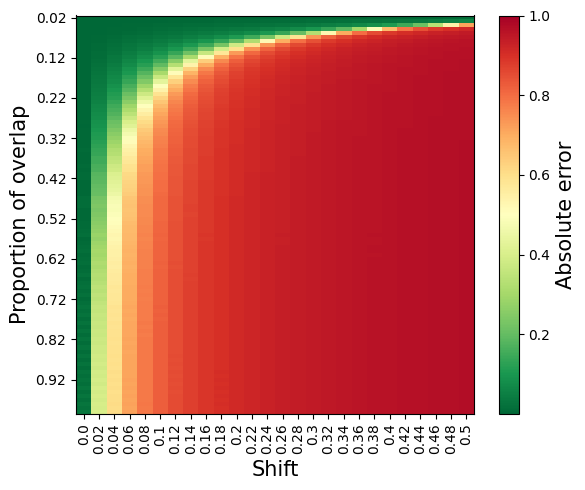

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

# Display heatmap
cax = ax.imshow(abs_error_df.values, cmap='RdYlGn_r', aspect='auto', vmax=1)

# Add colorbar to the figure
cbar = fig.colorbar(cax, ax=ax, label = 'Absolute error')
cbar.set_label(label='Absolute error', fontsize=15)

# Set axis ticks and labels
ax.set_xticks(range(len(abs_error_df.columns)))
ax.set_xticklabels([np.round(el, 2) for el in abs_error_df.columns], rotation=90)
ax.set_yticks(range(len(abs_error_df.index))[::10])
ax.set_yticklabels([np.round(el,3) for el in abs_error_df.index[::10]])
ax.set_xlabel("Shift", size=15)
ax.set_ylabel("Proportion of overlap", size=15)

# Layout adjustment
fig.tight_layout()

plt.savefig(results_path + 'error_heatmap_small_peak_proportion_'+ str(small_peak_proportion) + \
            '_shift_' + str(shift_diff) + '.png')